# CI-CIoT2023 Multiclass Intrusion Detection — Reproducible XGBoost Experiments

This notebook implements a paper-ready experimental protocol:

1. Inspect the original class distribution.
2. Cap each class at 50,000 samples for computational tractability (matching the existing workflow).
3. Remove `DDO`, which contains one sample.
4. Clean the 39 numerical features.
5. Create **one fixed stratified 80/10/10 train/validation/test split**.
6. Train a baseline XGBoost model using **validation data only** in `eval_set`.
7. Evaluate once on the untouched test set.
8. Run class weighting on **training data only**.
9. Run random oversampling on **training data only**.
10. Run random undersampling on **training data only**.
11. Compare Accuracy, Macro Precision/Recall/F1, Weighted F1, Balanced Accuracy, and per-class results.
12. Save results and confusion matrices for the paper.

> **Important:** The test set is never used for training, validation, sampling, class-weight calculation, or model selection.


## 1. Imports and configuration

In [6]:
import os
import glob
import gc
import json
import joblib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

RANDOM_STATE = 42
MAX_PER_CLASS = 50_000

TEST_SIZE = 0.10
VALIDATION_SIZE_WITHIN_REMAINDER = 0.50  # 10% validation + 10% test

N_ESTIMATORS = 300
MAX_DEPTH = 8
LEARNING_RATE = 0.1
SUBSAMPLE = 0.8
COLSAMPLE_BYTREE = 0.8

DATA_GLOB = "/kaggle/input/**/*.csv"

os.makedirs("/kaggle/working/paper_results", exist_ok=True)

print("Configuration loaded.")


Configuration loaded.


## 2. Locate the CI-CIoT2023 CSV files

In [7]:
csv_files = sorted(glob.glob(DATA_GLOB, recursive=True))

print("Total CSV files:", len(csv_files))
assert len(csv_files) == 63, f"Expected 63 CSV files, found {len(csv_files)}"

print("\nFirst 10 files:")
for f in csv_files[:10]:
    print(f)


Total CSV files: 0


AssertionError: Expected 63 CSV files, found 0

## 3. Inspect schema and original class distribution

The source files contain 40 columns: 39 numerical traffic features and `Label`.


In [5]:
sample = pd.read_csv(csv_files[0], nrows=5)

print("Number of columns:", len(sample.columns))
print("\nColumns:")
for i, col in enumerate(sample.columns):
    print(f"{i:2d} -> {col}")


Number of columns: 40

Columns:
 0 -> Header_Length
 1 -> Protocol Type
 2 -> Time_To_Live
 3 -> Rate
 4 -> fin_flag_number
 5 -> syn_flag_number
 6 -> rst_flag_number
 7 -> psh_flag_number
 8 -> ack_flag_number
 9 -> ece_flag_number
10 -> cwr_flag_number
11 -> ack_count
12 -> syn_count
13 -> fin_count
14 -> rst_count
15 -> HTTP
16 -> HTTPS
17 -> DNS
18 -> Telnet
19 -> SMTP
20 -> SSH
21 -> IRC
22 -> TCP
23 -> UDP
24 -> DHCP
25 -> ARP
26 -> ICMP
27 -> IGMP
28 -> IPv
29 -> LLC
30 -> Tot sum
31 -> Min
32 -> Max
33 -> AVG
34 -> Std
35 -> Tot size
36 -> IAT
37 -> Number
38 -> Variance
39 -> Label


In [6]:
label_counts = Counter()

for i, file in enumerate(csv_files, start=1):
    print(f"Scanning {i}/{len(csv_files)}", end="\r")

    for chunk in pd.read_csv(
        file,
        usecols=["Label"],
        chunksize=100_000
    ):
        label_counts.update(chunk["Label"].value_counts().to_dict())

original_distribution = (
    pd.Series(label_counts, name="Samples")
    .sort_values(ascending=False)
    .to_frame()
)
original_distribution["Percentage"] = (
    100 * original_distribution["Samples"] / original_distribution["Samples"].sum()
)

print("\nOriginal classes:", len(original_distribution))
display(original_distribution)


Scanning 63/63
Original classes: 35


,Samples,Percentage
DDOS-ICMP_FLOOD,6238116,15.313253
DDOS-UDP_FLOOD,4688853,11.510140
DDOS-TCP_FLOOD,3896380,9.564787
DDOS-PSHACK_FLOOD,3547143,8.707484
DDOS-SYN_FLOOD,3516170,8.631452
DDOS-RSTFINFLOOD,3504474,8.602741
DDOS-SYNONYMOUSIP_FLOOD,3117720,7.653342
DOS-UDP_FLOOD,2875284,7.058213
DOS-TCP_FLOOD,2314484,5.681568
DOS-SYN_FLOOD,1757714,4.314815


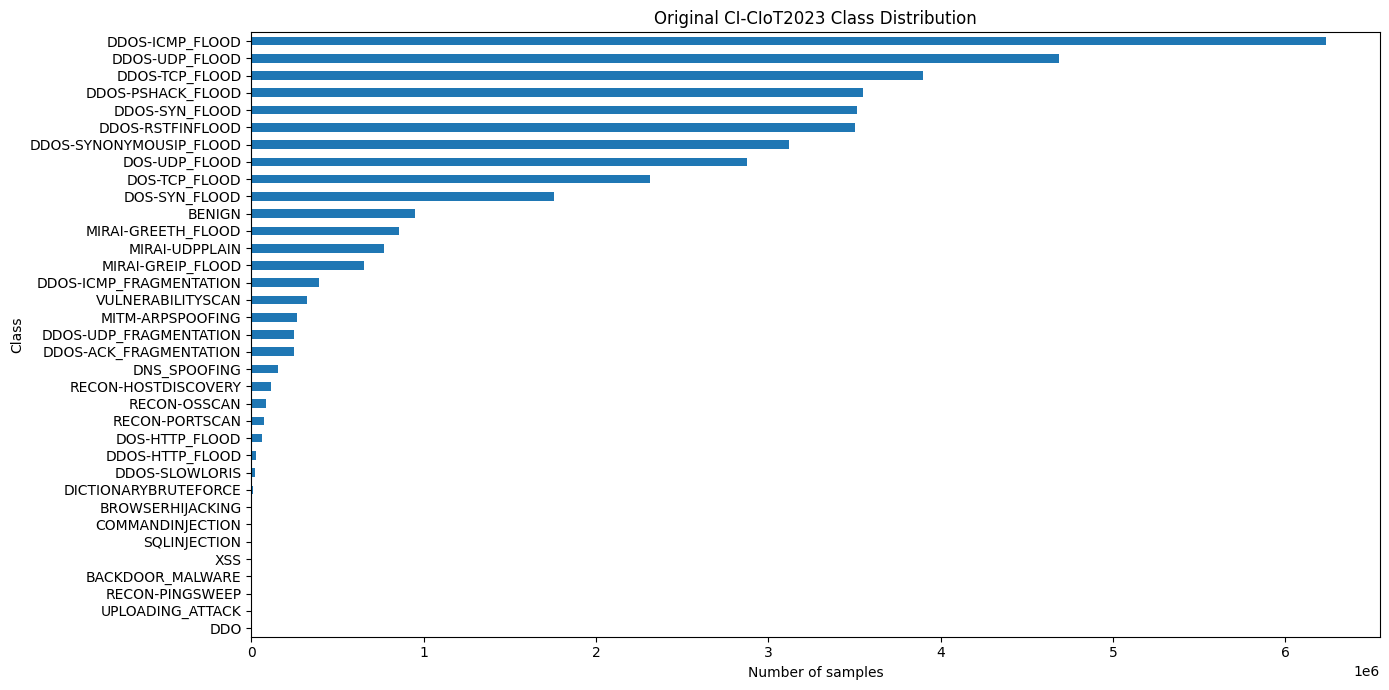

In [7]:
plt.figure(figsize=(14, 7))
original_distribution["Samples"].sort_values().plot(kind="barh")
plt.xlabel("Number of samples")
plt.ylabel("Class")
plt.title("Original CI-CIoT2023 Class Distribution")
plt.tight_layout()
plt.show()


## 4. Build the modeling dataset

The existing workflow limits each class to at most 50,000 samples. This is retained here for computational tractability.

**This is dataset construction, not the experimental undersampling strategy.** The later undersampling experiment is applied only to the training partition.


In [8]:
class_data = {label: [] for label in label_counts.keys()}
class_collected = {label: 0 for label in label_counts.keys()}

for file_num, file in enumerate(csv_files, start=1):
    print(f"Processing {file_num}/{len(csv_files)}: {os.path.basename(file)}")

    for chunk in pd.read_csv(file, chunksize=100_000):
        for label, group in chunk.groupby("Label"):
            remaining = MAX_PER_CLASS - class_collected[label]

            if remaining <= 0:
                continue

            if len(group) > remaining:
                group = group.sample(
                    n=remaining,
                    random_state=RANDOM_STATE
                )

            class_data[label].append(group)
            class_collected[label] += len(group)

        del chunk
        gc.collect()


Processing 1/63: Merged01.csv
Processing 2/63: Merged02.csv
Processing 3/63: Merged03.csv
Processing 4/63: Merged04.csv
Processing 5/63: Merged05.csv
Processing 6/63: Merged06.csv
Processing 7/63: Merged07.csv
Processing 8/63: Merged08.csv
Processing 9/63: Merged09.csv
Processing 10/63: Merged10.csv
Processing 11/63: Merged11.csv
Processing 12/63: Merged12.csv
Processing 13/63: Merged13.csv
Processing 14/63: Merged14.csv
Processing 15/63: Merged15.csv
Processing 16/63: Merged16.csv
Processing 17/63: Merged17.csv
Processing 18/63: Merged18.csv
Processing 19/63: Merged19.csv
Processing 20/63: Merged20.csv
Processing 21/63: Merged21.csv
Processing 22/63: Merged22.csv
Processing 23/63: Merged23.csv
Processing 24/63: Merged24.csv
Processing 25/63: Merged25.csv
Processing 26/63: Merged26.csv
Processing 27/63: Merged27.csv
Processing 28/63: Merged28.csv
Processing 29/63: Merged29.csv
Processing 30/63: Merged30.csv
Processing 31/63: Merged31.csv
Processing 32/63: Merged32.csv
Processing 33/63:

In [9]:
parts = []

for label, groups in class_data.items():
    if groups:
        class_df = pd.concat(groups, ignore_index=True)
        parts.append(class_df)

df = pd.concat(parts, ignore_index=True)

print("Capped modeling dataset:", df.shape)
print("\nSamples per class:")
display(df["Label"].value_counts().sort_values())


Capped modeling dataset: (1279948, 40)

Samples per class:


Label
DDO                            1
UPLOADING_ATTACK            1069
RECON-PINGSWEEP             1957
BACKDOOR_MALWARE            2797
XSS                         3309
SQLINJECTION                4526
COMMANDINJECTION            4695
BROWSERHIJACKING            5096
DICTIONARYBRUTEFORCE       11324
DDOS-SLOWLORIS             20261
DDOS-HTTP_FLOOD            24913
DDOS-ICMP_FLOOD            50000
DDOS-SYN_FLOOD             50000
DDOS-UDP_FLOOD             50000
DDOS-TCP_FLOOD             50000
DDOS-PSHACK_FLOOD          50000
DDOS-ICMP_FRAGMENTATION    50000
MITM-ARPSPOOFING           50000
MIRAI-GREIP_FLOOD          50000
MIRAI-UDPPLAIN             50000
MIRAI-GREETH_FLOOD         50000
BENIGN                     50000
DOS-SYN_FLOOD              50000
DOS-TCP_FLOOD              50000
DOS-HTTP_FLOOD             50000
RECON-PORTSCAN             50000
RECON-OSSCAN               50000
DNS_SPOOFING               50000
DDOS-ACK_FRAGMENTATION     50000
DDOS-SYNONYMOUSIP_FLOOD    50000
DDOS

## 5. Remove the one-sample `DDO` class

A class with one observation cannot support meaningful stratified train/validation/test evaluation, so it is excluded before the split.


In [10]:
print("Before removing DDO:", df.shape)

df = df[df["Label"] != "DDO"].copy()

print("After removing DDO:", df.shape)
print("Number of classes:", df["Label"].nunique())

model_distribution = (
    df["Label"]
    .value_counts()
    .sort_values(ascending=False)
    .to_frame("Samples")
)
model_distribution["Percentage"] = (
    100 * model_distribution["Samples"] / model_distribution["Samples"].sum()
)

display(model_distribution)


Before removing DDO: (1279948, 40)
After removing DDO: (1279947, 40)
Number of classes: 34


,Samples,Percentage
Label,,
DDOS-ICMP_FLOOD,50000,3.906412
DDOS-UDP_FLOOD,50000,3.906412
DDOS-TCP_FLOOD,50000,3.906412
DDOS-PSHACK_FLOOD,50000,3.906412
DDOS-SYN_FLOOD,50000,3.906412
DDOS-SYNONYMOUSIP_FLOOD,50000,3.906412
DDOS-RSTFINFLOOD,50000,3.906412
DOS-UDP_FLOOD,50000,3.906412
DOS-TCP_FLOOD,50000,3.906412


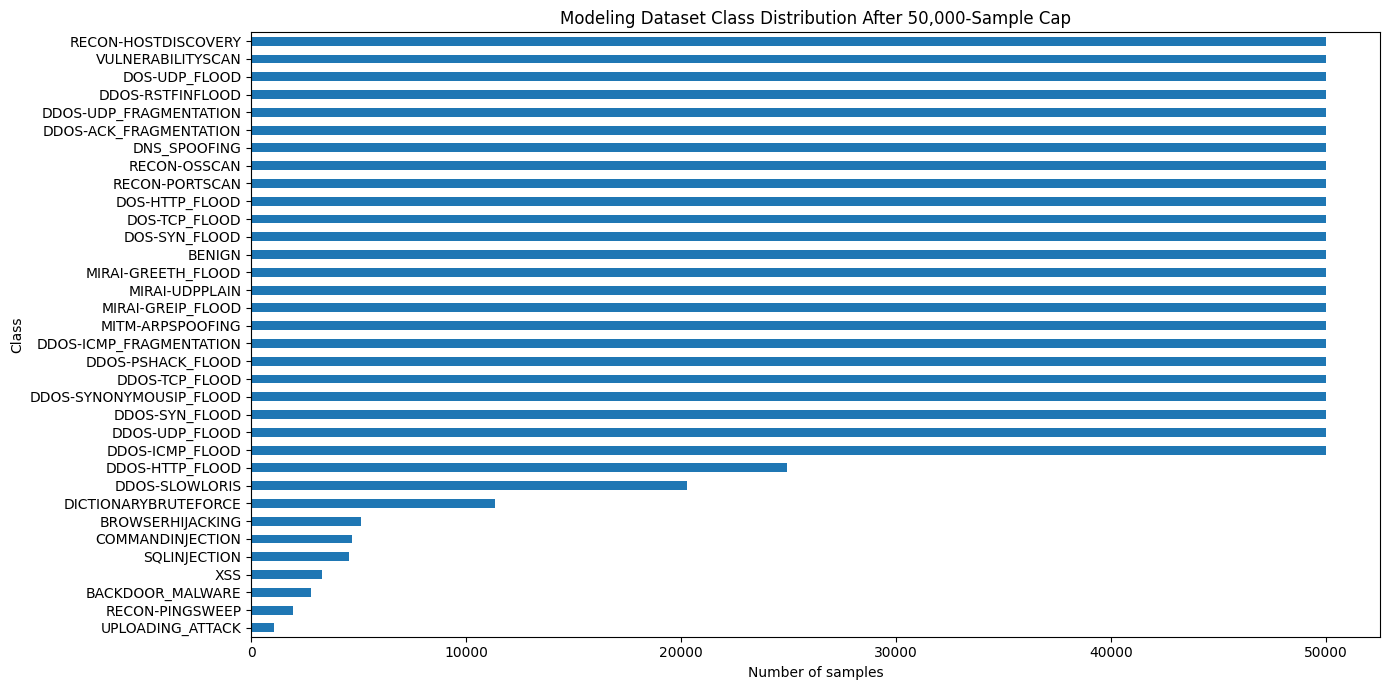

In [11]:
plt.figure(figsize=(14, 7))
model_distribution["Samples"].sort_values().plot(kind="barh")
plt.xlabel("Number of samples")
plt.ylabel("Class")
plt.title("Modeling Dataset Class Distribution After 50,000-Sample Cap")
plt.tight_layout()
plt.show()


## 6. Prepare features and labels

In [12]:
X = df.drop(columns=["Label"]).copy()
y = df["Label"].copy()

FEATURE_COLUMNS = X.columns.tolist()

print("Number of features:", len(FEATURE_COLUMNS))
print("Number of classes:", y.nunique())


Number of features: 39
Number of classes: 34


In [13]:
X = X.astype(np.float32)

X = X.replace([np.inf, -np.inf], np.nan)

missing_count = int(X.isna().sum().sum())
print("Missing/infinite-derived values:", missing_count)

X = X.fillna(0)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

CLASS_NAMES = label_encoder.classes_.tolist()
NUM_CLASSES = len(CLASS_NAMES)

print("Number of encoded classes:", NUM_CLASSES)
print("\nLabel mapping:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i:2d} -> {name}")


Missing/infinite-derived values: 104
Number of encoded classes: 34

Label mapping:
 0 -> BACKDOOR_MALWARE
 1 -> BENIGN
 2 -> BROWSERHIJACKING
 3 -> COMMANDINJECTION
 4 -> DDOS-ACK_FRAGMENTATION
 5 -> DDOS-HTTP_FLOOD
 6 -> DDOS-ICMP_FLOOD
 7 -> DDOS-ICMP_FRAGMENTATION
 8 -> DDOS-PSHACK_FLOOD
 9 -> DDOS-RSTFINFLOOD
10 -> DDOS-SLOWLORIS
11 -> DDOS-SYNONYMOUSIP_FLOOD
12 -> DDOS-SYN_FLOOD
13 -> DDOS-TCP_FLOOD
14 -> DDOS-UDP_FLOOD
15 -> DDOS-UDP_FRAGMENTATION
16 -> DICTIONARYBRUTEFORCE
17 -> DNS_SPOOFING
18 -> DOS-HTTP_FLOOD
19 -> DOS-SYN_FLOOD
20 -> DOS-TCP_FLOOD
21 -> DOS-UDP_FLOOD
22 -> MIRAI-GREETH_FLOOD
23 -> MIRAI-GREIP_FLOOD
24 -> MIRAI-UDPPLAIN
25 -> MITM-ARPSPOOFING
26 -> RECON-HOSTDISCOVERY
27 -> RECON-OSSCAN
28 -> RECON-PINGSWEEP
29 -> RECON-PORTSCAN
30 -> SQLINJECTION
31 -> UPLOADING_ATTACK
32 -> VULNERABILITYSCAN
33 -> XSS


## 7. Fixed stratified 80/10/10 split

This is the critical methodological change.

- **80% training:** used to fit models and apply sampling/weights.
- **10% validation:** used only for monitoring/model-selection decisions.
- **10% test:** completely untouched until final evaluation.

The same test set is reused for every imbalance strategy.


In [14]:
# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

# Second split: 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

del X_temp, y_temp, X, y, df, parts, class_data
gc.collect()

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (1023957, 39) (1023957,)
Validation: (127995, 39) (127995,)
Test: (127995, 39) (127995,)


In [15]:
def distribution_table(labels, encoder=label_encoder):
    counts = pd.Series(labels).value_counts().sort_index()
    out = pd.DataFrame({
        "Class": encoder.inverse_transform(counts.index),
        "Samples": counts.values
    })
    out["Percentage"] = 100 * out["Samples"] / out["Samples"].sum()
    return out.sort_values("Samples", ascending=False)

print("TRAIN distribution")
display(distribution_table(y_train))

print("VALIDATION distribution")
display(distribution_table(y_val))

print("TEST distribution")
display(distribution_table(y_test))


TRAIN distribution


,Class,Samples,Percentage
1,BENIGN,40000,3.906414
4,DDOS-ACK_FRAGMENTATION,40000,3.906414
26,RECON-HOSTDISCOVERY,40000,3.906414
8,DDOS-PSHACK_FLOOD,40000,3.906414
7,DDOS-ICMP_FRAGMENTATION,40000,3.906414
6,DDOS-ICMP_FLOOD,40000,3.906414
9,DDOS-RSTFINFLOOD,40000,3.906414
13,DDOS-TCP_FLOOD,40000,3.906414
12,DDOS-SYN_FLOOD,40000,3.906414
11,DDOS-SYNONYMOUSIP_FLOOD,40000,3.906414


VALIDATION distribution


,Class,Samples,Percentage
1,BENIGN,5000,3.906403
4,DDOS-ACK_FRAGMENTATION,5000,3.906403
26,RECON-HOSTDISCOVERY,5000,3.906403
8,DDOS-PSHACK_FLOOD,5000,3.906403
7,DDOS-ICMP_FRAGMENTATION,5000,3.906403
6,DDOS-ICMP_FLOOD,5000,3.906403
9,DDOS-RSTFINFLOOD,5000,3.906403
13,DDOS-TCP_FLOOD,5000,3.906403
12,DDOS-SYN_FLOOD,5000,3.906403
11,DDOS-SYNONYMOUSIP_FLOOD,5000,3.906403


TEST distribution


,Class,Samples,Percentage
1,BENIGN,5000,3.906403
4,DDOS-ACK_FRAGMENTATION,5000,3.906403
26,RECON-HOSTDISCOVERY,5000,3.906403
8,DDOS-PSHACK_FLOOD,5000,3.906403
7,DDOS-ICMP_FRAGMENTATION,5000,3.906403
6,DDOS-ICMP_FLOOD,5000,3.906403
9,DDOS-RSTFINFLOOD,5000,3.906403
13,DDOS-TCP_FLOOD,5000,3.906403
12,DDOS-SYN_FLOOD,5000,3.906403
11,DDOS-SYNONYMOUSIP_FLOOD,5000,3.906403


## 8. XGBoost model factory

All experiments use the same XGBoost architecture and hyperparameters. Only the imbalance treatment changes.


In [16]:
def make_xgb():
    return XGBClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        subsample=SUBSAMPLE,
        colsample_bytree=COLSAMPLE_BYTREE,
        objective="multi:softprob",
        num_class=NUM_CLASSES,
        eval_metric="mlogloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )


## 9. Evaluation utilities

Macro F1 is treated as a primary metric because it gives every class equal importance under class imbalance.


In [17]:
def evaluate_model(model, X_eval, y_eval, name, save_prefix=None):
    y_pred = model.predict(X_eval)

    report_dict = classification_report(
        y_eval,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Macro Precision": precision_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_eval, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_eval, y_pred, average="weighted", zero_division=0
        ),
    }

    print(f"\n===== {name} =====")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_eval,
            y_pred,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_eval, y_pred)

    if save_prefix:
        pd.DataFrame(report_dict).T.to_csv(
            f"/kaggle/working/paper_results/{save_prefix}_classification_report.csv"
        )
        pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
            f"/kaggle/working/paper_results/{save_prefix}_confusion_matrix.csv"
        )

    return metrics, y_pred, cm


# Experiment 1 — Baseline XGBoost

The validation set is supplied to `eval_set`. The test set is not passed to `.fit()`.


In [18]:
baseline_model = make_xgb()

baseline_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)


[0]	validation_0-mlogloss:2.49869
[1]	validation_0-mlogloss:2.19490
[2]	validation_0-mlogloss:1.97937
[3]	validation_0-mlogloss:1.81492
[4]	validation_0-mlogloss:1.68250
[5]	validation_0-mlogloss:1.56979
[6]	validation_0-mlogloss:1.47388
[7]	validation_0-mlogloss:1.39106
[8]	validation_0-mlogloss:1.31904
[9]	validation_0-mlogloss:1.25464
[10]	validation_0-mlogloss:1.19851
[11]	validation_0-mlogloss:1.14774
[12]	validation_0-mlogloss:1.10231
[13]	validation_0-mlogloss:1.06140
[14]	validation_0-mlogloss:1.02456
[15]	validation_0-mlogloss:0.99111
[16]	validation_0-mlogloss:0.96077
[17]	validation_0-mlogloss:0.93330
[18]	validation_0-mlogloss:0.90837
[19]	validation_0-mlogloss:0.88541
[20]	validation_0-mlogloss:0.86459
[21]	validation_0-mlogloss:0.84558
[22]	validation_0-mlogloss:0.82801
[23]	validation_0-mlogloss:0.81198
[24]	validation_0-mlogloss:0.79714
[25]	validation_0-mlogloss:0.78340
[26]	validation_0-mlogloss:0.77097
[27]	validation_0-mlogloss:0.75931
[28]	validation_0-mlogloss:0.7

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=34, ...)

In [19]:
baseline_metrics, baseline_pred, baseline_cm = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    name="Baseline XGBoost",
    save_prefix="baseline"
)

joblib.dump(
    baseline_model,
    "/kaggle/working/paper_results/baseline_xgboost.joblib"
)



===== Baseline XGBoost =====
Accuracy: 0.7592
Balanced Accuracy: 0.6408
Macro Precision: 0.7081
Macro Recall: 0.6408
Macro F1: 0.6497
Weighted F1: 0.7518

Classification report:
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.38      0.15      0.22       280
                 BENIGN       0.53      0.73      0.62      5000
       BROWSERHIJACKING       0.71      0.33      0.45       509
       COMMANDINJECTION       0.57      0.34      0.43       469
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      5000
        DDOS-HTTP_FLOOD       0.91      0.82      0.86      2492
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      5000
DDOS-ICMP_FRAGMENTATION       0.99      0.99      0.99      5000
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00      5000
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      5000
         DDOS-SLOWLORIS       0.93      0.98      0.96      2026
DDOS-SYNONYMOUSIP_FLOOD       0.45      

['/kaggle/working/paper_results/baseline_xgboost.joblib']

In [20]:
baseline_summary = pd.DataFrame([baseline_metrics])
display(baseline_summary)


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Baseline XGBoost,0.759209,0.640808,0.708096,0.640808,0.649726,0.751802


## Baseline per-class evidence

For the paper, the complete classification report can be saved as supplementary material. In the main paper, a compact table can highlight classes with low support and/or poor F1.


In [21]:
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        baseline_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).T

baseline_per_class = baseline_report.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]
baseline_per_class["support"] = baseline_per_class["support"].astype(int)

display(
    baseline_per_class
    .sort_values("f1-score")
    .head(10)
)


,precision,recall,f1-score,support
UPLOADING_ATTACK,0.250000,0.046729,0.078740,107
RECON-PINGSWEEP,0.461538,0.061224,0.108108,196
XSS,0.229358,0.075529,0.113636,331
SQLINJECTION,0.760000,0.084071,0.151394,452
BACKDOOR_MALWARE,0.383929,0.153571,0.219388,280
DDOS-SYN_FLOOD,0.482585,0.249400,0.328850,5000
RECON-OSSCAN,0.431869,0.269400,0.331814,5000
COMMANDINJECTION,0.571429,0.341151,0.427236,469
RECON-PORTSCAN,0.512655,0.397000,0.447475,5000
BROWSERHIJACKING,0.710638,0.328094,0.448925,509


# Experiment 2 — Class-weighted XGBoost

Weights are computed **from the training labels only**. The validation and test sets are untouched.

For multiclass classification, each training sample receives the weight of its class.


In [22]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_map = dict(zip(classes, class_weights_array))

class_weight_table = pd.DataFrame({
    "Encoded Class": classes,
    "Class": label_encoder.inverse_transform(classes),
    "Training Samples": [np.sum(y_train == c) for c in classes],
    "Weight": class_weights_array
}).sort_values("Weight", ascending=False)

display(class_weight_table)


,Encoded Class,Class,Training Samples,Weight
31,31,UPLOADING_ATTACK,855,35.223839
28,28,RECON-PINGSWEEP,1566,19.231406
0,0,BACKDOOR_MALWARE,2237,13.462844
33,33,XSS,2647,11.377553
30,30,SQLINJECTION,3621,8.317145
3,3,COMMANDINJECTION,3756,8.018206
2,2,BROWSERHIJACKING,4077,7.386898
16,16,DICTIONARYBRUTEFORCE,9059,3.324471
10,10,DDOS-SLOWLORIS,16209,1.858004
5,5,DDOS-HTTP_FLOOD,19930,1.511108


In [23]:
# Per-sample weights for the training data only
sample_weights = np.array(
    [class_weight_map[int(label)] for label in y_train],
    dtype=np.float32
)

weighted_model = make_xgb()

weighted_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=True
)


[0]	validation_0-mlogloss:2.52556
[1]	validation_0-mlogloss:2.23719
[2]	validation_0-mlogloss:2.02683
[3]	validation_0-mlogloss:1.86777
[4]	validation_0-mlogloss:1.73979
[5]	validation_0-mlogloss:1.63038
[6]	validation_0-mlogloss:1.53750
[7]	validation_0-mlogloss:1.45637
[8]	validation_0-mlogloss:1.38636
[9]	validation_0-mlogloss:1.32383
[10]	validation_0-mlogloss:1.26945
[11]	validation_0-mlogloss:1.22024
[12]	validation_0-mlogloss:1.17571
[13]	validation_0-mlogloss:1.13567
[14]	validation_0-mlogloss:1.09967
[15]	validation_0-mlogloss:1.06692
[16]	validation_0-mlogloss:1.03735
[17]	validation_0-mlogloss:1.01062
[18]	validation_0-mlogloss:0.98590
[19]	validation_0-mlogloss:0.96347
[20]	validation_0-mlogloss:0.94304
[21]	validation_0-mlogloss:0.92447
[22]	validation_0-mlogloss:0.90742
[23]	validation_0-mlogloss:0.89161
[24]	validation_0-mlogloss:0.87711
[25]	validation_0-mlogloss:0.86337
[26]	validation_0-mlogloss:0.85100
[27]	validation_0-mlogloss:0.83937
[28]	validation_0-mlogloss:0.8

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=34, ...)

In [24]:
weighted_metrics, weighted_pred, weighted_cm = evaluate_model(
    weighted_model,
    X_test,
    y_test,
    name="Class-Weighted XGBoost",
    save_prefix="class_weighted"
)

joblib.dump(
    weighted_model,
    "/kaggle/working/paper_results/class_weighted_xgboost.joblib"
)



===== Class-Weighted XGBoost =====
Accuracy: 0.7457
Balanced Accuracy: 0.6631
Macro Precision: 0.6346
Macro Recall: 0.6631
Macro F1: 0.6352
Weighted F1: 0.7474

Classification report:
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.11      0.31      0.16       280
                 BENIGN       0.57      0.68      0.62      5000
       BROWSERHIJACKING       0.24      0.56      0.34       509
       COMMANDINJECTION       0.25      0.39      0.30       469
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      5000
        DDOS-HTTP_FLOOD       0.86      0.87      0.86      2492
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      5000
DDOS-ICMP_FRAGMENTATION       0.99      0.99      0.99      5000
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00      5000
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      5000
         DDOS-SLOWLORIS       0.93      0.99      0.96      2026
DDOS-SYNONYMOUSIP_FLOOD       0.45

['/kaggle/working/paper_results/class_weighted_xgboost.joblib']

# Experiment 3 — Random Oversampling

Oversampling is applied **only to the training partition**.

The validation and test distributions remain unchanged.

The default target is the maximum training-class count. If this produces an excessively large training set in your environment, lower `OVERSAMPLE_TARGET` and report the chosen target explicitly in the paper.


In [25]:
train_counts = pd.Series(y_train).value_counts()
OVERSAMPLE_TARGET = int(train_counts.max())

print("Oversampling target per class:", OVERSAMPLE_TARGET)
print("Original training rows:", len(y_train))
print("Potential oversampled rows:", OVERSAMPLE_TARGET * NUM_CLASSES)


Oversampling target per class: 40000
Original training rows: 1023957
Potential oversampled rows: 1360000


In [26]:
def random_oversample_training(X_in, y_in, target_count, random_state=42):
    X_parts = []
    y_parts = []

    y_series = pd.Series(y_in, index=X_in.index)

    for cls in sorted(y_series.unique()):
        cls_idx = y_series[y_series == cls].index

        if len(cls_idx) < target_count:
            sampled_idx = resample(
                cls_idx,
                replace=True,
                n_samples=target_count,
                random_state=random_state
            )
        else:
            sampled_idx = cls_idx

        X_parts.append(X_in.loc[sampled_idx])
        y_parts.append(y_series.loc[sampled_idx])

    X_out = pd.concat(X_parts, axis=0).reset_index(drop=True)
    y_out = pd.concat(y_parts, axis=0).to_numpy()

    shuffle_idx = np.random.default_rng(random_state).permutation(len(y_out))

    return (
        X_out.iloc[shuffle_idx].reset_index(drop=True),
        y_out[shuffle_idx]
    )


In [27]:
X_train_over, y_train_over = random_oversample_training(
    X_train,
    y_train,
    target_count=OVERSAMPLE_TARGET,
    random_state=RANDOM_STATE
)

print("Oversampled training shape:", X_train_over.shape)
display(distribution_table(y_train_over))


Oversampled training shape: (1360000, 39)


,Class,Samples,Percentage
0,BACKDOOR_MALWARE,40000,2.941176
1,BENIGN,40000,2.941176
2,BROWSERHIJACKING,40000,2.941176
3,COMMANDINJECTION,40000,2.941176
4,DDOS-ACK_FRAGMENTATION,40000,2.941176
5,DDOS-HTTP_FLOOD,40000,2.941176
6,DDOS-ICMP_FLOOD,40000,2.941176
7,DDOS-ICMP_FRAGMENTATION,40000,2.941176
8,DDOS-PSHACK_FLOOD,40000,2.941176
9,DDOS-RSTFINFLOOD,40000,2.941176


In [28]:
oversampled_model = make_xgb()

oversampled_model.fit(
    X_train_over,
    y_train_over,
    eval_set=[(X_val, y_val)],
    verbose=True
)


[0]	validation_0-mlogloss:2.52218
[1]	validation_0-mlogloss:2.23454
[2]	validation_0-mlogloss:2.02457
[3]	validation_0-mlogloss:1.86619
[4]	validation_0-mlogloss:1.73852
[5]	validation_0-mlogloss:1.62949
[6]	validation_0-mlogloss:1.53696
[7]	validation_0-mlogloss:1.45610
[8]	validation_0-mlogloss:1.38632
[9]	validation_0-mlogloss:1.32392
[10]	validation_0-mlogloss:1.26947
[11]	validation_0-mlogloss:1.22014
[12]	validation_0-mlogloss:1.17562
[13]	validation_0-mlogloss:1.13584
[14]	validation_0-mlogloss:1.09998
[15]	validation_0-mlogloss:1.06714
[16]	validation_0-mlogloss:1.03740
[17]	validation_0-mlogloss:1.01065
[18]	validation_0-mlogloss:0.98617
[19]	validation_0-mlogloss:0.96375
[20]	validation_0-mlogloss:0.94332
[21]	validation_0-mlogloss:0.92473
[22]	validation_0-mlogloss:0.90750
[23]	validation_0-mlogloss:0.89160
[24]	validation_0-mlogloss:0.87710
[25]	validation_0-mlogloss:0.86354
[26]	validation_0-mlogloss:0.85123
[27]	validation_0-mlogloss:0.83962
[28]	validation_0-mlogloss:0.8

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=34, ...)

In [29]:
oversampled_metrics, oversampled_pred, oversampled_cm = evaluate_model(
    oversampled_model,
    X_test,
    y_test,
    name="Random Oversampling + XGBoost",
    save_prefix="oversampled"
)

joblib.dump(
    oversampled_model,
    "/kaggle/working/paper_results/oversampled_xgboost.joblib"
)

del X_train_over, y_train_over
gc.collect()



===== Random Oversampling + XGBoost =====
Accuracy: 0.7445
Balanced Accuracy: 0.6636
Macro Precision: 0.6351
Macro Recall: 0.6636
Macro F1: 0.6348
Weighted F1: 0.7467

Classification report:
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.11      0.34      0.16       280
                 BENIGN       0.57      0.68      0.62      5000
       BROWSERHIJACKING       0.24      0.53      0.33       509
       COMMANDINJECTION       0.28      0.38      0.32       469
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      5000
        DDOS-HTTP_FLOOD       0.86      0.86      0.86      2492
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      5000
DDOS-ICMP_FRAGMENTATION       0.99      0.99      0.99      5000
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00      5000
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      5000
         DDOS-SLOWLORIS       0.93      0.99      0.96      2026
DDOS-SYNONYMOUSIP_FLOOD    

36

# Experiment 4 — Random Undersampling

Undersampling is also applied **only to the training partition**.

Here we use the smallest training class as the target count. This is intentionally aggressive; if it discards too much majority-class information, a less aggressive target can be tested as a sensitivity experiment.


In [30]:
UNDERSAMPLE_TARGET = int(train_counts.min())

print("Undersampling target per class:", UNDERSAMPLE_TARGET)
print("Original training rows:", len(y_train))
print("Undersampled rows:", UNDERSAMPLE_TARGET * NUM_CLASSES)


Undersampling target per class: 855
Original training rows: 1023957
Undersampled rows: 29070


In [31]:
def random_undersample_training(X_in, y_in, target_count, random_state=42):
    X_parts = []
    y_parts = []

    y_series = pd.Series(y_in, index=X_in.index)

    for cls in sorted(y_series.unique()):
        cls_idx = y_series[y_series == cls].index

        if len(cls_idx) > target_count:
            sampled_idx = resample(
                cls_idx,
                replace=False,
                n_samples=target_count,
                random_state=random_state
            )
        else:
            sampled_idx = cls_idx

        X_parts.append(X_in.loc[sampled_idx])
        y_parts.append(y_series.loc[sampled_idx])

    X_out = pd.concat(X_parts, axis=0).reset_index(drop=True)
    y_out = pd.concat(y_parts, axis=0).to_numpy()

    shuffle_idx = np.random.default_rng(random_state).permutation(len(y_out))

    return (
        X_out.iloc[shuffle_idx].reset_index(drop=True),
        y_out[shuffle_idx]
    )


In [32]:
X_train_under, y_train_under = random_undersample_training(
    X_train,
    y_train,
    target_count=UNDERSAMPLE_TARGET,
    random_state=RANDOM_STATE
)

print("Undersampled training shape:", X_train_under.shape)
display(distribution_table(y_train_under))


Undersampled training shape: (29070, 39)


,Class,Samples,Percentage
0,BACKDOOR_MALWARE,855,2.941176
1,BENIGN,855,2.941176
2,BROWSERHIJACKING,855,2.941176
3,COMMANDINJECTION,855,2.941176
4,DDOS-ACK_FRAGMENTATION,855,2.941176
5,DDOS-HTTP_FLOOD,855,2.941176
6,DDOS-ICMP_FLOOD,855,2.941176
7,DDOS-ICMP_FRAGMENTATION,855,2.941176
8,DDOS-PSHACK_FLOOD,855,2.941176
9,DDOS-RSTFINFLOOD,855,2.941176


In [33]:
undersampled_model = make_xgb()

undersampled_model.fit(
    X_train_under,
    y_train_under,
    eval_set=[(X_val, y_val)],
    verbose=True
)


[0]	validation_0-mlogloss:2.61581
[1]	validation_0-mlogloss:2.32176
[2]	validation_0-mlogloss:2.10877
[3]	validation_0-mlogloss:1.94693
[4]	validation_0-mlogloss:1.81721
[5]	validation_0-mlogloss:1.70601
[6]	validation_0-mlogloss:1.61255
[7]	validation_0-mlogloss:1.53156
[8]	validation_0-mlogloss:1.46047
[9]	validation_0-mlogloss:1.39791
[10]	validation_0-mlogloss:1.34252
[11]	validation_0-mlogloss:1.29307
[12]	validation_0-mlogloss:1.24822
[13]	validation_0-mlogloss:1.20812
[14]	validation_0-mlogloss:1.17167
[15]	validation_0-mlogloss:1.13828
[16]	validation_0-mlogloss:1.10817
[17]	validation_0-mlogloss:1.08116
[18]	validation_0-mlogloss:1.05658
[19]	validation_0-mlogloss:1.03392
[20]	validation_0-mlogloss:1.01337
[21]	validation_0-mlogloss:0.99472
[22]	validation_0-mlogloss:0.97731
[23]	validation_0-mlogloss:0.96131
[24]	validation_0-mlogloss:0.94679
[25]	validation_0-mlogloss:0.93330
[26]	validation_0-mlogloss:0.92065
[27]	validation_0-mlogloss:0.90883
[28]	validation_0-mlogloss:0.8

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=34, ...)

In [34]:
undersampled_metrics, undersampled_pred, undersampled_cm = evaluate_model(
    undersampled_model,
    X_test,
    y_test,
    name="Random Undersampling + XGBoost",
    save_prefix="undersampled"
)

joblib.dump(
    undersampled_model,
    "/kaggle/working/paper_results/undersampled_xgboost.joblib"
)

del X_train_under, y_train_under
gc.collect()



===== Random Undersampling + XGBoost =====
Accuracy: 0.6975
Balanced Accuracy: 0.6341
Macro Precision: 0.5976
Macro Recall: 0.6341
Macro F1: 0.5950
Weighted F1: 0.7072

Classification report:
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.07      0.30      0.11       280
                 BENIGN       0.57      0.52      0.54      5000
       BROWSERHIJACKING       0.17      0.50      0.25       509
       COMMANDINJECTION       0.21      0.33      0.26       469
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      5000
        DDOS-HTTP_FLOOD       0.73      0.84      0.78      2492
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      5000
DDOS-ICMP_FRAGMENTATION       1.00      0.98      0.99      5000
      DDOS-PSHACK_FLOOD       1.00      0.99      1.00      5000
       DDOS-RSTFINFLOOD       1.00      1.00      1.00      5000
         DDOS-SLOWLORIS       0.83      0.98      0.90      2026
DDOS-SYNONYMOUSIP_FLOOD   

48

# Final comparison

All four approaches are evaluated on the **same untouched test set**.

For this project, Macro F1 and Macro Recall are especially important because the objective is to evaluate detection performance across attack categories rather than allowing large classes to dominate the aggregate score.


In [35]:
results = pd.DataFrame([
    baseline_metrics,
    weighted_metrics,
    oversampled_metrics,
    undersampled_metrics
])

results = results[
    [
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ]
]

display(
    results.style.format({
        col: "{:.4f}" for col in results.columns if col != "Model"
    })
)

results.to_csv(
    "/kaggle/working/paper_results/model_comparison.csv",
    index=False
)


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Baseline XGBoost,0.7592,0.6408,0.7081,0.6408,0.6497,0.7518
1,Class-Weighted XGBoost,0.7457,0.6631,0.6346,0.6631,0.6352,0.7474
2,Random Oversampling + XGBoost,0.7445,0.6636,0.6351,0.6636,0.6348,0.7467
3,Random Undersampling + XGBoost,0.6975,0.6341,0.5976,0.6341,0.5950,0.7072


## Per-class comparison

This table is useful for the paper because an imbalance technique can improve macro metrics while helping some attack classes more than others.


In [36]:
def compact_per_class_report(y_true, y_pred, model_name):
    report = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        )
    ).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]

    report = report.rename(columns={
        "precision": f"{model_name} Precision",
        "recall": f"{model_name} Recall",
        "f1-score": f"{model_name} F1",
        "support": f"{model_name} Support",
    })
    return report

reports = [
    compact_per_class_report(y_test, baseline_pred, "Baseline"),
    compact_per_class_report(y_test, weighted_pred, "Weighted"),
    compact_per_class_report(y_test, oversampled_pred, "Oversampled"),
    compact_per_class_report(y_test, undersampled_pred, "Undersampled"),
]

per_class_comparison = pd.concat(reports, axis=1)

display(
    per_class_comparison.sort_values("Baseline F1").head(15)
)

per_class_comparison.to_csv(
    "/kaggle/working/paper_results/per_class_comparison.csv"
)


,Baseline Precision,Baseline Recall,Baseline F1,Baseline Support,Weighted Precision,Weighted Recall,Weighted F1,Weighted Support,Oversampled Precision,Oversampled Recall,Oversampled F1,Oversampled Support,Undersampled Precision,Undersampled Recall,Undersampled F1,Undersampled Support
UPLOADING_ATTACK,0.250000,0.046729,0.078740,107.0,0.054622,0.121495,0.075362,107.0,0.036697,0.112150,0.055300,107.0,0.030576,0.317757,0.055783,107.0
RECON-PINGSWEEP,0.461538,0.061224,0.108108,196.0,0.047045,0.198980,0.076098,196.0,0.051060,0.270408,0.085900,196.0,0.038612,0.403061,0.070473,196.0
XSS,0.229358,0.075529,0.113636,331.0,0.085659,0.268882,0.129927,331.0,0.080184,0.262840,0.122881,331.0,0.073016,0.277946,0.115651,331.0
SQLINJECTION,0.760000,0.084071,0.151394,452.0,0.078889,0.314159,0.126110,452.0,0.077260,0.311947,0.123847,452.0,0.062943,0.353982,0.106880,452.0
BACKDOOR_MALWARE,0.383929,0.153571,0.219388,280.0,0.109137,0.307143,0.161049,280.0,0.106622,0.339286,0.162254,280.0,0.070364,0.303571,0.114247,280.0
DDOS-SYN_FLOOD,0.482585,0.249400,0.328850,5000.0,0.494347,0.253600,0.335228,5000.0,0.494695,0.251800,0.333731,5000.0,0.388189,0.332600,0.358251,5000.0
RECON-OSSCAN,0.431869,0.269400,0.331814,5000.0,0.462602,0.227600,0.305094,5000.0,0.455450,0.219800,0.296506,5000.0,0.341253,0.198200,0.250759,5000.0
COMMANDINJECTION,0.571429,0.341151,0.427236,469.0,0.248985,0.392324,0.304636,469.0,0.275229,0.383795,0.320570,469.0,0.206897,0.332623,0.255110,469.0
RECON-PORTSCAN,0.512655,0.397000,0.447475,5000.0,0.532874,0.371200,0.437581,5000.0,0.530495,0.368800,0.435111,5000.0,0.429183,0.280600,0.339340,5000.0
BROWSERHIJACKING,0.710638,0.328094,0.448925,509.0,0.244406,0.557957,0.339916,509.0,0.238387,0.534381,0.329697,509.0,0.168449,0.495088,0.251372,509.0


## Confusion matrices

The raw matrices are saved to CSV. For 34 classes, the plotted matrix is intentionally large; use the saved matrix for exact paper analysis and create a publication-sized figure after deciding whether to show all classes or a selected subset.


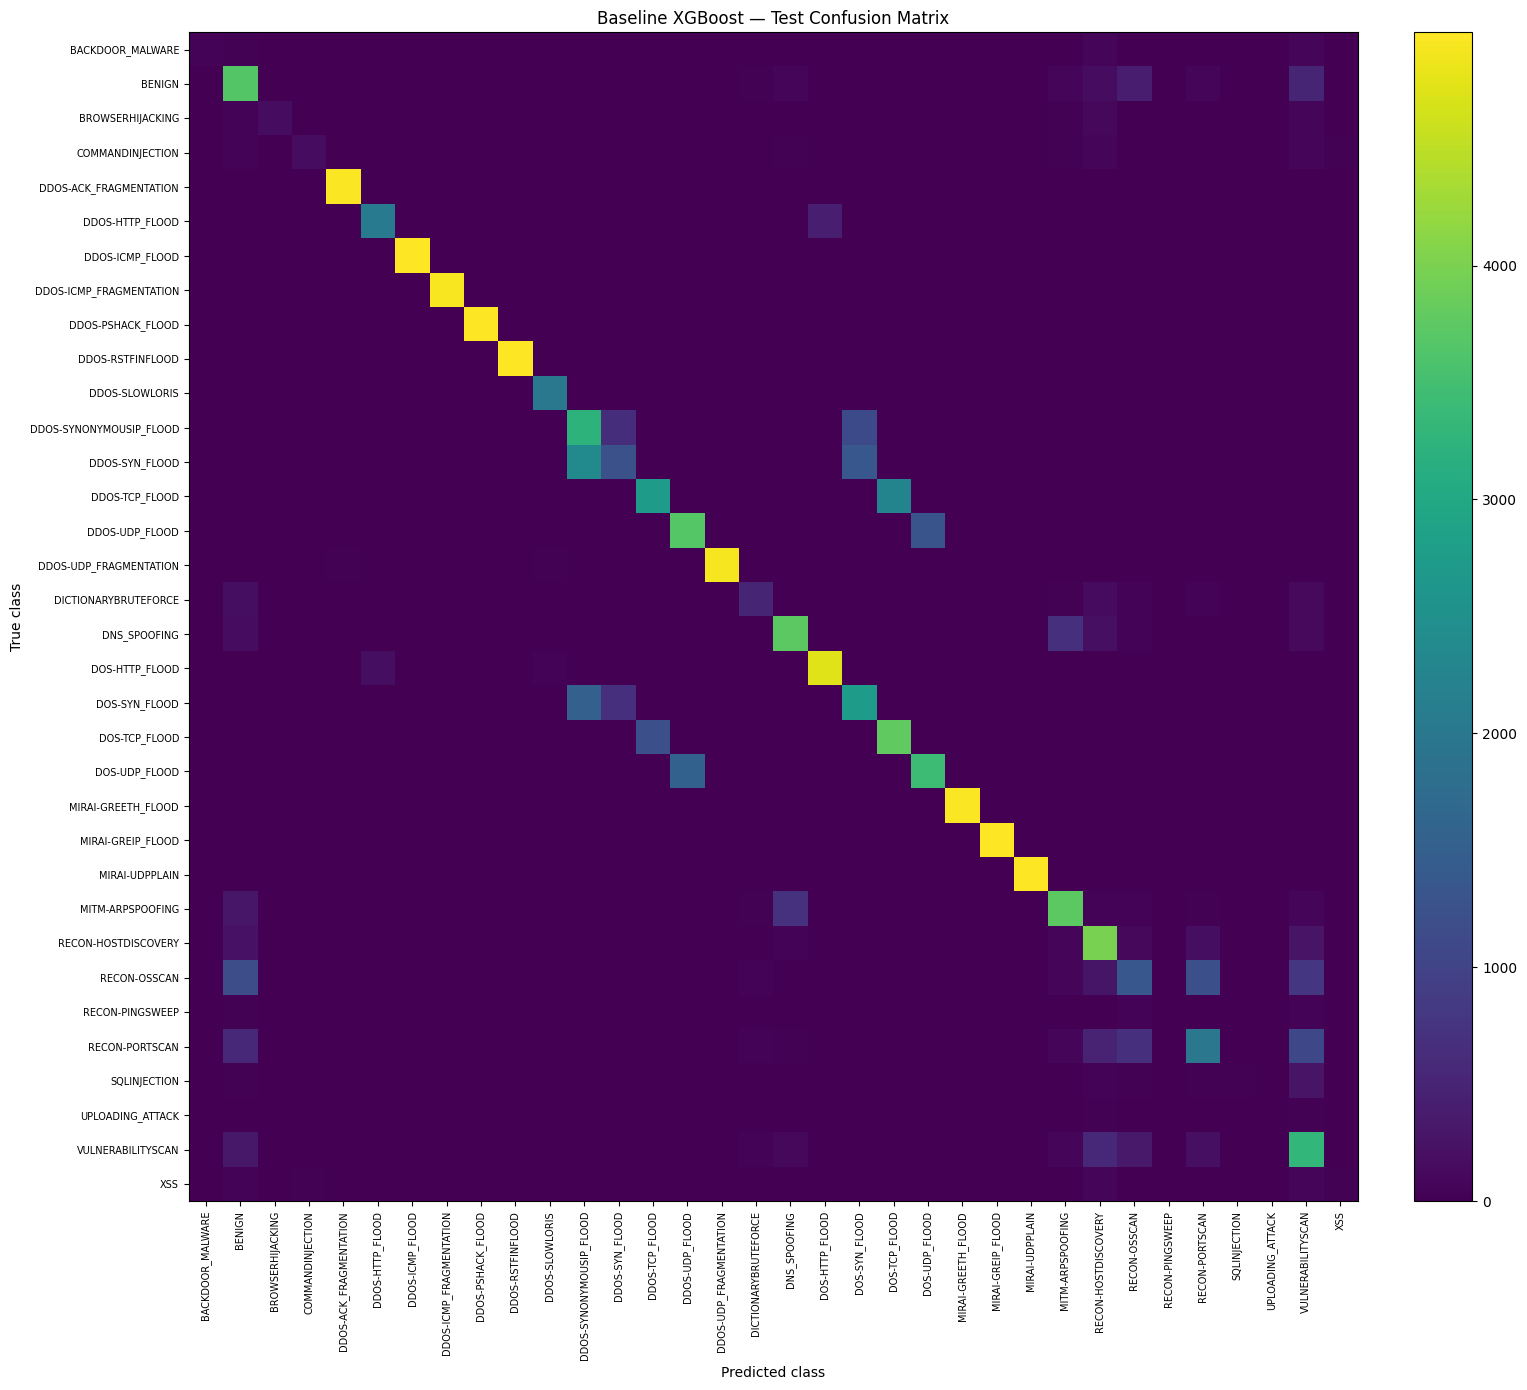

In [37]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(16, 14))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

    ax.set_xticks(np.arange(NUM_CLASSES))
    ax.set_yticks(np.arange(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    baseline_cm,
    "Baseline XGBoost — Test Confusion Matrix"
)


# Paper-ready outputs

The `/kaggle/working/paper_results/` directory contains:

- `model_comparison.csv` — main comparison table
- `per_class_comparison.csv` — per-class comparison
- classification reports for every model
- confusion matrices for every model
- saved XGBoost models

Recommended main-paper evidence:

1. **Table:** original/modeling class distribution.
2. **Table:** Baseline vs weighting vs oversampling vs undersampling.
3. **Table or supplementary material:** per-class precision/recall/F1.
4. **Figure:** class distribution.
5. **Figure:** confusion matrix, if space permits.

Keep the complete classification reports and matrices as supplementary material if the conference page limit is tight.


## XGBoost Hyperparameter Tuning

In [1]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    objective="multi:softprob",
    num_class=34,

    n_estimators=1000,
    learning_rate=0.03,

    max_depth=6,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.1,
    reg_lambda=2.0,

    eval_metric="mlogloss",
    tree_method="hist",

    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

In [8]:
# xgb_tuned.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_val, y_val)],
#     verbose=False
# )